# EDA Presentation: Online Shopping Purchase Intent

## Objective
Predict whether a session ends with a purchase (`PurchaseCompleted`) by understanding behavior patterns and data quality constraints.

## What this notebook does
1. Loads and profiles the dataset.
2. Assesses data quality (missingness, invalid values, outliers, imbalance).
3. Explores purchase behavior by numeric and categorical factors.
4. Summarizes actionable implications for downstream modeling and business decisions.

## Feature Schema Reference

Understanding the domain meaning of each feature is critical for proper data cleaning and interpretation:

### Numeric Features (Bounded Rates)
- **BounceRate** (0.0-1.0): Percentage of single-page sessions on the website
- **ExitRate** (0.0-1.0): Percentage of users who exit from a specific page after viewing it
  - Formula: (Number of exits from a page) / (Total views of that page)
- **SpecialDayProximity** (0.0-1.0): Proximity score to special events *(NOT a day count)*
  - 0.0 = not close to special day
  - 0.2 = slightly close
  - 0.4 = moderately close
  - 0.6 = getting closer
  - 0.8 = very close
  - 1.0 = the special day itself

### Numeric Features (Continuous)
- **PageValue**: Page contribution to revenue
  - Formula: (Total e-commerce revenue + goal value) / unique pageviews
  - ⭐ **Strongest predictor** in feature importance analysis (81.7%)
- **ProductPageTime**: Average time spent on product pages in **seconds**
  - Range: 0-738s (0-12+ minutes)
  - High variability; typical sessions 1-2 minutes but can be much longer

### Categorical Features (Coded)
- **TrafficSource**: Numeric codes (1-5) representing traffic channels
  - Examples: organic search, paid ads, direct visits
  - Treated as categorical, not ordinal
- **GeographicRegion**: Numeric codes for geographic regions
  - Positive codes (1-4): known regions
  - Negative codes (-9, -3, etc.): unknown/special regions
  - Treated as categorical, not ordinal
- **CustomerType**: Visitor classification
  - Values: returning_visitor, new_visitor, other

### Target
- **PurchaseCompleted** (0/1): Binary indicator of whether the session resulted in a purchase

In [10]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

DATA_PATH = 'online_shopping'
TARGET = 'PurchaseCompleted'

# Step 1: Load data and inspect structure
raw_df = pd.read_csv(
    DATA_PATH,
    na_values=['NULL', 'nan', 'None', ''],
    keep_default_na=True,
)

print('Dataset shape:', raw_df.shape)
print('\nColumns:', list(raw_df.columns))
print('\nData types:\n', raw_df.dtypes)
raw_df.head()

Dataset shape: (12330, 9)

Columns: ['CustomerType', 'SpecialDayProximity', 'ExitRate', 'PageValue', 'TrafficSource', 'GeographicRegion', 'BounceRate', 'ProductPageTime', 'PurchaseCompleted']

Data types:
 CustomerType               str
SpecialDayProximity    float64
ExitRate               float64
PageValue              float64
TrafficSource          float64
GeographicRegion         int64
BounceRate             float64
ProductPageTime        float64
PurchaseCompleted        int64
dtype: object


,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
0,Returning_Visitor,0.0,0.20,0.0,1.0,1,0.20,0.000000,0
1,Returning_Visitor,0.0,0.10,0.0,2.0,1,0.00,64.000000,0
2,Returning_Visitor,NaN,0.20,0.0,3.0,-9,0.20,0.000000,0
3,Returning_Visitor,0.0,0.14,0.0,4.0,2,0.05,2.666667,0
4,Returning_Visitor,0.0,NaN,NaN,4.0,1,0.02,627.500000,0


Missing percentage by feature:
 SpecialDayProximity    5.00
ProductPageTime        5.00
ExitRate               5.00
PageValue              5.00
TrafficSource          5.00
CustomerType           3.83
GeographicRegion       0.00
BounceRate             0.00
PurchaseCompleted      0.00
dtype: float64

Invalid value counts:
- BounceRate outside [0,1]: 348
- ExitRate outside [0,1]: 0
- SpecialDayProximity outside [0,1]: 0

Duplicate rows: 395

Class distribution (count):
 PurchaseCompleted
0    10422
1     1908
Name: count, dtype: int64

Class distribution (%):
 PurchaseCompleted
0    84.53
1    15.47
Name: proportion, dtype: float64


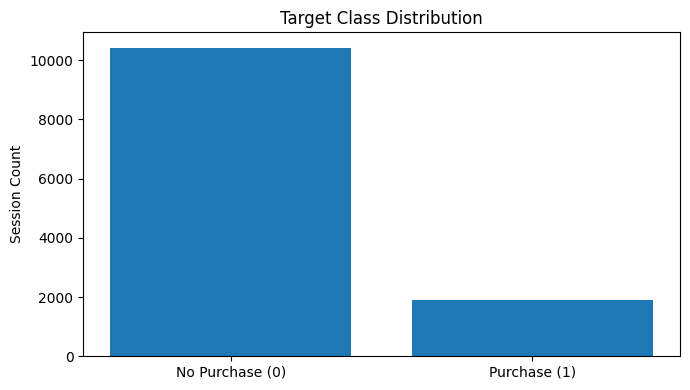


Missing values after cleanup (%):

SpecialDayProximity    5.00
ProductPageTime        5.00
ExitRate               5.00
PageValue              5.00
TrafficSource          5.00
CustomerType           3.83
BounceRate             2.82
GeographicRegion       0.00
PurchaseCompleted      0.00
dtype: float64


In [14]:
# Step 2: Data quality diagnostics and domain cleanup
quality_df = raw_df.copy()

invalid_counts = {
    'BounceRate outside [0,1]': int(((quality_df['BounceRate'] < 0) | (quality_df['BounceRate'] > 1)).sum()),
    'ExitRate outside [0,1]': int(((quality_df['ExitRate'] < 0) | (quality_df['ExitRate'] > 1)).sum()),
    'SpecialDayProximity outside [0,1]': int(((quality_df['SpecialDayProximity'] < 0) | (quality_df['SpecialDayProximity'] > 1)).sum()),
}

missing_pct = (quality_df.isna().mean() * 100).sort_values(ascending=False).round(2)

print('Missing percentage by feature:\n', missing_pct)
print('\nInvalid value counts:')
for k, v in invalid_counts.items():
    print(f'- {k}: {v}')

print('\nDuplicate rows:', int(quality_df.duplicated().sum()))

class_dist = quality_df[TARGET].value_counts().sort_index()
class_pct = (quality_df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2)
print('\nClass distribution (count):\n', class_dist)
print('\nClass distribution (%):\n', class_pct)

# Matplotlib bar chart for class distribution
labels = ['No Purchase (0)', 'Purchase (1)']
values = [class_dist.get(0, 0), class_dist.get(1, 0)]

plt.figure(figsize=(7, 4))
plt.bar(labels, values)
plt.title('Target Class Distribution')
plt.ylabel('Session Count')
plt.tight_layout()
plt.show()

# Domain-aware cleanup for downstream analysis
eda_df = raw_df.copy()
for c in ['BounceRate', 'ExitRate']:
    eda_df.loc[(eda_df[c] < 0) | (eda_df[c] > 1), c] = np.nan

eda_df.loc[
    (eda_df['SpecialDayProximity'] < 0) | (eda_df['SpecialDayProximity'] > 1),
    'SpecialDayProximity',
] = np.nan

eda_df['CustomerType'] = eda_df['CustomerType'].astype('string').str.strip().str.lower()

print('\nMissing values after cleanup (%):\n')
print((eda_df.isna().mean() * 100).round(2).sort_values(ascending=False))

## Final Conclusions and Implications

### Key Findings
1. The target is imbalanced, so recall/F1 and threshold tuning are necessary for fair model evaluation.
2. `PageValue` and `ProductPageTime` are strong positive signals of purchase intent.
3. `ExitRate` and `BounceRate` show negative relationships with purchase completion.
4. Conversion rates vary by `CustomerType`, `TrafficSource`, and `GeographicRegion`.

### Impact on Modeling Choices
- Apply domain-aware cleaning for bounded features.
- Treat coded source/region fields as categories.
- Use stratified splits and compare multiple models.
- Tune decision threshold for the business objective.

### Business Implications
- Prioritize users with high page value and high product engagement.
- Reduce exit/bounce behavior on high-intent pages through UX interventions.
- Allocate campaigns by high-converting traffic and region segments.

In [ ]:
# Step 3: Business implications table 
baseline_cr = eda_df[TARGET].mean()

# Build simple, business-friendly segments
pagevalue_positive = eda_df['PageValue'] > 0
if pagevalue_positive.any():
    high_pagevalue_cut = np.nanpercentile(eda_df.loc[pagevalue_positive, 'PageValue'], 75)
else:
    high_pagevalue_cut = np.nan

high_time_cut = np.nanpercentile(eda_df['ProductPageTime'], 75)
low_exit_cut = np.nanpercentile(eda_df['ExitRate'], 25)
low_bounce_cut = np.nanpercentile(eda_df['BounceRate'], 25)

segments = {
    'High PageValue sessions (top quartile of >0)': pagevalue_positive & (eda_df['PageValue'] >= high_pagevalue_cut),
    'High ProductPageTime sessions (top quartile)': eda_df['ProductPageTime'] >= high_time_cut,
    'Low ExitRate sessions (bottom quartile)': eda_df['ExitRate'] <= low_exit_cut,
    'Low BounceRate sessions (bottom quartile)': eda_df['BounceRate'] <= low_bounce_cut,
}

rows = []
for name, mask in segments.items():
    seg = eda_df.loc[mask, TARGET]
    seg_cr = seg.mean()
    lift_pct = ((seg_cr / baseline_cr) - 1.0) * 100 if baseline_cr > 0 else np.nan
    rows.append({
        'segment': name,
        'sessions': int(seg.shape[0]),
        'segment_conversion_rate': round(float(seg_cr), 4),
        'baseline_conversion_rate': round(float(baseline_cr), 4),
        'lift_vs_baseline_pct': round(float(lift_pct), 2),
    })

implications_df = pd.DataFrame(rows).sort_values('lift_vs_baseline_pct', ascending=False)
implications_df['recommended_action'] = np.where(
    implications_df['lift_vs_baseline_pct'] > 0,
    'Prioritize and target this segment',
    'Monitor and optimize experience for this segment',
)

print(f'Baseline conversion rate: {baseline_cr:.4f}')
implications_df

Baseline conversion rate: 0.1547


,segment,sessions,segment_conversion_rate,baseline_conversion_rate,lift_vs_baseline_pct,recommended_action
0,High PageValue sessions (top quartile of >0),651,0.7834,0.1547,406.26,Prioritize and target this segment
2,Low ExitRate sessions (bottom quartile),3012,0.2673,0.1547,72.71,Prioritize and target this segment
1,High ProductPageTime sessions (top quartile),2929,0.2352,0.1547,52.01,Prioritize and target this segment
3,Low BounceRate sessions (bottom quartile),5518,0.1877,0.1547,21.33,Prioritize and target this segment


PurchaseCompleted,0,1
SpecialDayProximity,0.067880,0.022527
ExitRate,0.047383,0.019573
PageValue,1.966342,27.352521
BounceRate,0.024807,0.004892
ProductPageTime,1075.257542,1874.588073


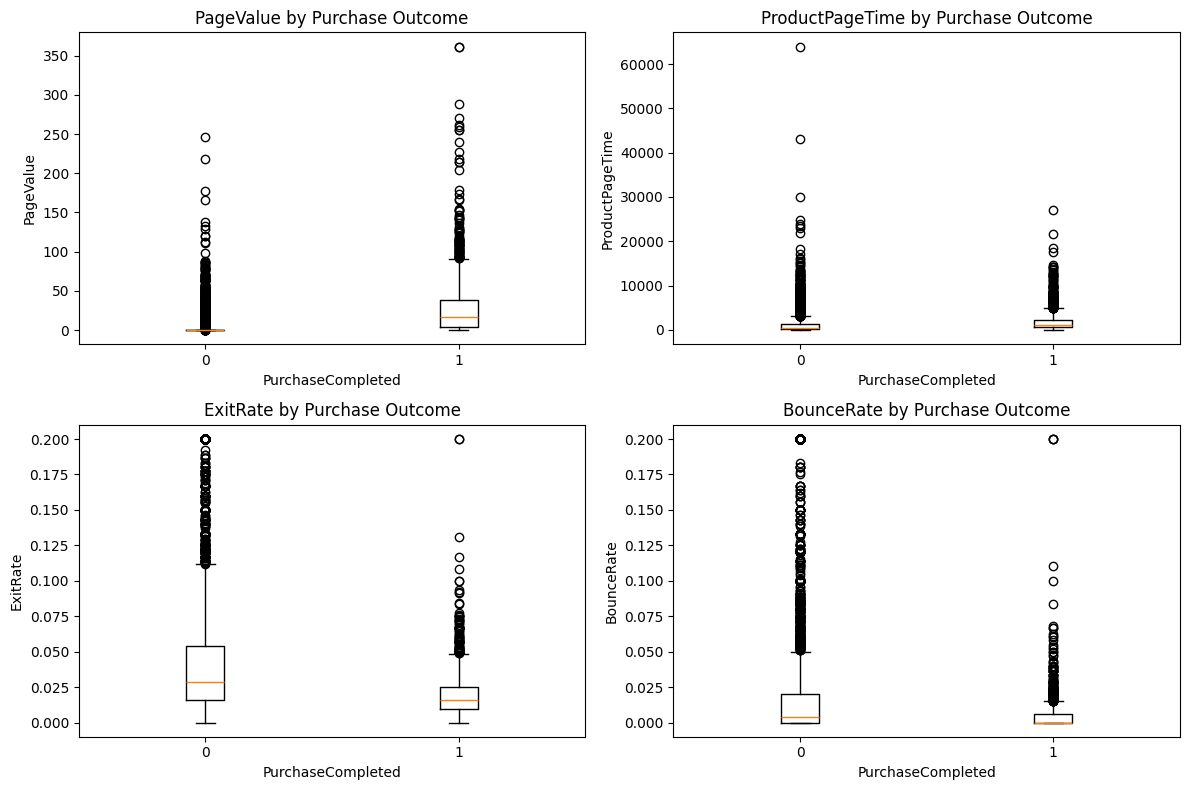

In [16]:
# Step 4: Numeric features vs purchase outcome
num_cols = ['SpecialDayProximity', 'ExitRate', 'PageValue', 'BounceRate', 'ProductPageTime']

mean_by_target = eda_df.groupby(TARGET)[num_cols].mean().T
display(mean_by_target)

plot_cols = ['PageValue', 'ProductPageTime', 'ExitRate', 'BounceRate']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    non_purchase = eda_df.loc[eda_df[TARGET] == 0, col].dropna()
    purchase = eda_df.loc[eda_df[TARGET] == 1, col].dropna()
    ax.boxplot([non_purchase, purchase], labels=['0', '1'])
    ax.set_title(f'{col} by Purchase Outcome')
    ax.set_xlabel('PurchaseCompleted')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### Interpretation: Numeric Drivers
- Purchasing sessions generally show higher `PageValue` and longer `ProductPageTime`, indicating stronger buying intent.
- `ExitRate` and `BounceRate` are lower for purchase sessions, suggesting deeper and more engaged browsing behavior.
- These patterns support using value/engagement metrics as primary predictive features.

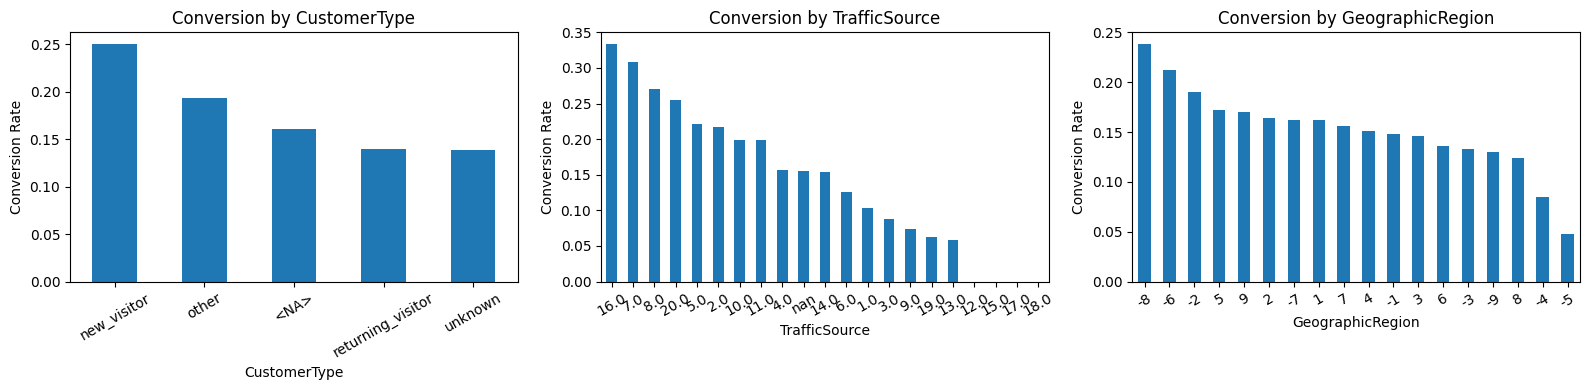

In [17]:
# Step 5: Segment-level conversion rates
customer_conv = (
    eda_df.groupby('CustomerType', dropna=False)[TARGET]
    .mean()
    .sort_values(ascending=False)
)

traffic_conv = (
    eda_df.groupby('TrafficSource', dropna=False)[TARGET]
    .mean()
    .sort_values(ascending=False)
)

region_conv = (
    eda_df.groupby('GeographicRegion', dropna=False)[TARGET]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

customer_conv.plot(kind='bar', ax=axes[0], title='Conversion by CustomerType')
axes[0].set_ylabel('Conversion Rate')
axes[0].tick_params(axis='x', rotation=30)

traffic_conv.plot(kind='bar', ax=axes[1], title='Conversion by TrafficSource')
axes[1].set_ylabel('Conversion Rate')
axes[1].tick_params(axis='x', rotation=30)

region_conv.plot(kind='bar', ax=axes[2], title='Conversion by GeographicRegion')
axes[2].set_ylabel('Conversion Rate')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Interpretation: Data Quality
- Missing values are non-trivial in several predictors and must be explicitly handled before model training.
- Bounded-rate variables include invalid values, indicating realistic data noise that should be corrected.
- The target is imbalanced (far more non-purchase sessions), so precision/recall trade-offs matter more than accuracy alone.

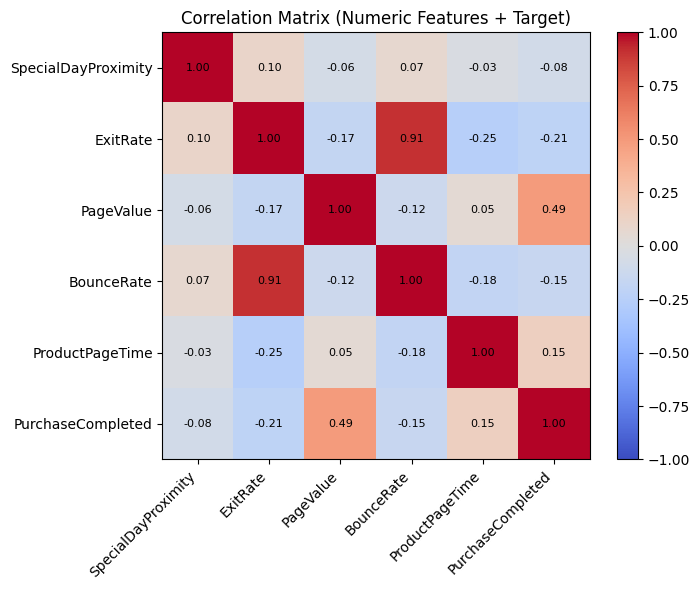

Correlation with target:

PurchaseCompleted      1.000000
PageValue              0.492046
ProductPageTime        0.149756
SpecialDayProximity   -0.083206
BounceRate            -0.149680
ExitRate              -0.207794
Name: PurchaseCompleted, dtype: float64


In [18]:
# Step 6: Correlation analysis
corr_cols = ['SpecialDayProximity', 'ExitRate', 'PageValue', 'BounceRate', 'ProductPageTime', TARGET]
corr = eda_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Matrix (Numeric Features + Target)')

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print('Correlation with target:\n')
print(corr[TARGET].sort_values(ascending=False))

## EDA Process Roadmap

### Step 1: Data Loading and Schema Audit
Purpose: Verify shape, feature types, and target definition before any analysis.

### Step 2: Data Quality Diagnostics and Domain Cleanup
Purpose: Quantify missing values, invalid ranges, class imbalance, and prepare cleaned data for downstream analysis.

### Step 3: Business Implications Table
Purpose: Translate top behavioral signals into actionable segment-level conversion lifts.

### Step 4: Univariate and Bivariate Exploration
Purpose: Understand how numeric features differ between purchase and non-purchase sessions.

### Step 5: Segment-Level Conversion Analysis
Purpose: Compare conversion performance across customer, traffic, and region segments.

### Step 6: Correlation and Signal Strength Review
Purpose: Identify strongest candidate features and potential redundancy.